# Dense periodic n=1: Granger causality and TDMI

This notebook completes the first stage of Linus' exercise for the dense periodic $n=1$ reference model. It asks whether the binary event indicator Granger-predicts volatility and whether their signed-lag mutual information is consistent with the known event-leading timing. Both directions are examined; volatility-leading results are a false-reverse-edge diagnostic.

## 2. Scope and interpretation

The known structural graph is E_i -> omega_(i+1) -> sigma_(i+1). Granger causality is an incremental linear predictive test, and TDMI is a nonlinear lagged-dependence measure; neither alone proves structural causality. This notebook does not estimate weights, forecast, analyse real data, or implement later-stage methods.

## 3. Imports

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

pd.set_option('display.precision', 6)

## 4. Load Notebook 00 silently

The core notebook is executed silently so that its reusable functions and reference configuration enter this namespace without reproducing its plots or printed validation output. No simulator or core functional form is redefined below.

In [2]:
%%capture
%run "./00_model_specification_and_core_simulator.ipynb"

## 5. Reconstruct the dense periodic n=1 reference path

The new path uses the imported simulation engine and the imported reference configuration. Event times end at the final transition source time, not the terminal state time.

In [3]:
required_core_names = {
    'simulate_event_volatility', 'alpha_fn', 'nu_fn', 'rho_fn',
    'event_weight_fn', 'periodic_event_times', 'reference_config'
}
assert required_core_names.issubset(globals())

model_params = reference_config['model']
event_params = reference_config['events']
simulation_params = reference_config['simulation']
event_period_steps = reference_timing['event_period_steps']
response_horizon_steps = reference_timing['response_horizon_steps']
response_state_lag_start = reference_timing['response_state_lag_start']
response_state_lag_end = reference_timing['response_state_lag_end']
event_responses_overlap = reference_timing['event_responses_overlap']
trading_steps_per_year = reference_timing['steps_per_year']
first_cycle_lag_start = response_state_lag_start
first_cycle_lag_end = event_period_steps
tdmi_scan_max_lag = event_period_steps + response_state_lag_end
assert model_params['n'] == 1

steps_per_year = trading_steps_per_year
n_steps = simulation_params['years'] * steps_per_year
time_grid = np.arange(n_steps + 1, dtype=float) / steps_per_year
event_times = periodic_event_times(time_grid[0], time_grid[-2], event_params)
dense_result = simulate_event_volatility(
    time_grid=time_grid,
    S0=simulation_params['S0'],
    sigma0=simulation_params['sigma0'],
    n=model_params['n'],
    alpha_fn=alpha_fn,
    nu_fn=nu_fn,
    rho_fn=rho_fn,
    event_weight_fn=event_weight_fn,
    model_params=model_params,
    event_times=event_times,
    event_params=event_params,
    seed=simulation_params['seed'],
)

states = dense_result['states']
transitions = dense_result['transitions']
states_snapshot = states.copy(deep=True)
transitions_snapshot = transitions.copy(deep=True)
print(f'n = {model_params["n"]}; event period = {event_period_steps} trading steps; response horizon = {response_horizon_steps} transition ages; direct state-response lags = {response_state_lag_start} to {response_state_lag_end}.')
if event_responses_overlap:
    print('WARNING: event-response windows overlap; first-cycle peaks cannot isolate one event response.')
else:
    print('Event responses do not overlap: the original response ends before the next event affects volatility.')
print(f'Generated exact event times: {len(event_times)}')

n = 1; event period = 21 trading steps; response horizon = 12 transition ages; direct state-response lags = 1 to 13.
Event responses do not overlap: the original response ends before the next event affects volatility.
Generated exact event times: 23


## 6. Build and validate the aligned analysis table

The primary state-indexed series pair is sigma_t = sigma_i and E_t = E_i. Both refer to source time t_i. Because the event affects the transition into the next state, an event-leading effect is expected at positive delay, E_t -> sigma_(t+1); `sigma_next` is retained only as a descriptive transition outcome.

In [4]:
analysis_table = pd.DataFrame({
    't': transitions['t'].to_numpy(),
    'sigma_t': states.iloc[:-1]['sigma'].to_numpy(),
    'event_t': transitions['event'].to_numpy(),
    'sigma_next': transitions['sigma_next'].to_numpy(),
    'omega_next': transitions['omega_next'].to_numpy(),
})
analysis_table['delta_sigma_next'] = analysis_table['sigma_next'] - analysis_table['sigma_t']
analysis_table['active_event_response'] = analysis_table['omega_next'] > 1.0

assert len(analysis_table) == len(transitions)
np.testing.assert_allclose(analysis_table['sigma_t'], states.iloc[:-1]['sigma'])
np.testing.assert_allclose(analysis_table['sigma_next'], transitions['sigma_next'])
assert set(analysis_table['event_t'].unique()).issubset({0, 1})
assert analysis_table[['sigma_t', 'event_t']].notna().all().all()
assert len(event_times) == int(analysis_table['event_t'].sum())
event_indices = np.flatnonzero(analysis_table['event_t'].to_numpy() == 1)
assert np.all(np.diff(event_indices) == event_period_steps)
assert event_params['response_horizon'] < event_params['period']

event_fraction = float(analysis_table['event_t'].mean())
active_response_fraction = float(analysis_table['active_event_response'].mean())
print(f'Event-indicator fraction: {event_fraction:.6f}')
print(f'Active-weight transition fraction: {active_response_fraction:.6f}')
analysis_table.head()

Event-indicator fraction: 0.045635
Active-weight transition fraction: 0.593254


,t,sigma_t,event_t,sigma_next,omega_next,delta_sigma_next,active_event_response
0,0.000000,0.200000,0,0.199041,1.0,-0.000959,False
1,0.003968,0.199041,0,0.197175,1.0,-0.001866,False
2,0.007937,0.197175,0,0.196176,1.0,-0.000999,False
3,0.011905,0.196176,0,0.197132,1.0,0.000956,False
4,0.015873,0.197132,0,0.195876,1.0,-0.001256,False


## 7. Descriptive event-effect check

This comparison describes the simulated association between a source-time event and the following volatility change. It is not a causal test because it does not condition on history or distinguish periodic-calendar predictability.

          count      mean       std    median
event_t                                      
No event    481  0.000074  0.001021  0.000166
Event        23  0.000842  0.001085  0.000899


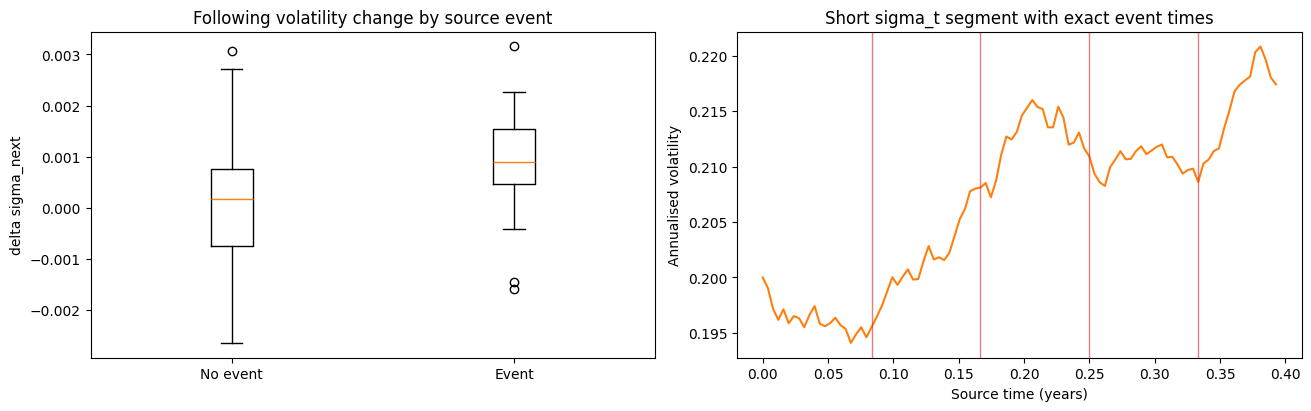

In [5]:
event_effect_summary = (
    analysis_table.groupby('event_t')['delta_sigma_next']
    .agg(['count', 'mean', 'std', 'median'])
    .rename(index={0: 'No event', 1: 'Event'})
)
print(event_effect_summary)

segment_end = min(100, len(analysis_table))
segment = analysis_table.iloc[:segment_end]
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].boxplot(
    [
        analysis_table.loc[analysis_table['event_t'].eq(0), 'delta_sigma_next'],
        analysis_table.loc[analysis_table['event_t'].eq(1), 'delta_sigma_next'],
    ],
    tick_labels=['No event', 'Event'],
)
axes[0].set(title='Following volatility change by source event', ylabel='delta sigma_next')
axes[1].plot(segment['t'], segment['sigma_t'], color='tab:orange')
for event_time in segment.loc[segment['event_t'].eq(1), 't']:
    axes[1].axvline(event_time, color='tab:red', alpha=0.6, linewidth=1)
axes[1].set(title='Short sigma_t segment with exact event times', xlabel='Source time (years)', ylabel='Annualised volatility')
plt.show()

## 8. Granger-causality methodology

For target $y_t$ and candidate driver $x_t$, the restricted regression contains a constant and $p$ historical target lags. The unrestricted regression additionally contains the same $p$ historical driver lags. The null is that all driver-lag coefficients are zero. With $N$ effective observations, the nested-regression statistic is $F=((RSS_r-RSS_u)/p)/(RSS_u/(N-2p-1))$, and its upper-tail p-value uses `scipy.stats.f.sf`. `log_variance_ratio = log(RSS_r/RSS_u)` summarizes the incremental fit.

## 9. Manual nested-regression F-test

In [6]:
def granger_f_test(target, driver, lag):
    target = np.asarray(target, dtype=float)
    driver = np.asarray(driver, dtype=float)
    if target.ndim != 1 or driver.ndim != 1 or target.size != driver.size:
        raise ValueError('target and driver must be equal-length one-dimensional arrays.')
    if lag < 1 or target.size <= 2 * lag + 1:
        raise ValueError('lag leaves insufficient observations for the unrestricted regression.')

    n_obs = target.size - lag
    response = target[lag:]
    target_lags = np.column_stack([target[lag - j: target.size - j] for j in range(1, lag + 1)])
    driver_lags = np.column_stack([driver[lag - j: driver.size - j] for j in range(1, lag + 1)])
    restricted = sm.OLS(response, sm.add_constant(target_lags, has_constant='add')).fit()
    unrestricted = sm.OLS(
        response, sm.add_constant(np.column_stack([target_lags, driver_lags]), has_constant='add')
    ).fit()

    rss_restricted = float(restricted.ssr)
    rss_unrestricted = float(unrestricted.ssr)
    residual_df = int(unrestricted.df_resid)
    if rss_unrestricted > rss_restricted + 1e-10:
        raise AssertionError('Unrestricted RSS exceeds restricted RSS beyond numerical tolerance.')
    if residual_df <= 0:
        raise AssertionError('Unrestricted regression has non-positive residual degrees of freedom.')

    f_stat = ((rss_restricted - rss_unrestricted) / lag) / (rss_unrestricted / residual_df)
    p_value = float(stats.f.sf(f_stat, lag, residual_df))
    return {
        'lag': lag,
        'n_obs': n_obs,
        'rss_restricted': rss_restricted,
        'rss_unrestricted': rss_unrestricted,
        'f_stat': float(f_stat),
        'p_value': p_value,
        'residual_df': residual_df,
        'log_variance_ratio': float(np.log(rss_restricted / rss_unrestricted)),
    }


def granger_results_table(target, driver, max_lag):
    return pd.DataFrame([granger_f_test(target, driver, lag) for lag in range(1, max_lag + 1)])


sigma_t = analysis_table['sigma_t'].to_numpy()
event_t = analysis_table['event_t'].to_numpy(dtype=float)
existing_gc_max_lag = 20
response_window_gc_order = response_state_lag_end
max_gc_lag = max(existing_gc_max_lag, response_window_gc_order)
max_lag = max_gc_lag
direct_timing_lag = 1
response_window_lag = response_window_gc_order

# Each design row at source index i uses only columns indexed i-j, where j is at least one.
for lag in range(1, max_lag + 1):
    current_indices = np.arange(lag, len(sigma_t))
    historical_indices = np.column_stack([np.arange(lag - j, len(sigma_t) - j) for j in range(1, lag + 1)])
    assert np.all(historical_indices < current_indices[:, None])

## 10. Granger results: event -> volatility

Here the target is sigma_t and the driver is E_t. Rejection means that historical events Granger-predict source-indexed volatility after its own lagged history is included. Lag 13 is pre-specified because the weight is active on the event transition and the following 12 transitions; the complete scan is exploratory sensitivity analysis.

Direct one-step timing check (p = 1):
lag                                     1
n_obs                                 503
rss_restricted                   0.000537
rss_unrestricted                 0.000524
f_stat                          12.094457
p_value                           0.00055
residual_df                           500
log_variance_ratio               0.023901
direction             event -> volatility
Full event-response-window lag order (p = 13):
lag                                    13
n_obs                                 491
rss_restricted                   0.000494
rss_unrestricted                 0.000442
f_stat                           4.190183
p_value                          0.000001
residual_df                           464
log_variance_ratio               0.111002
direction             event -> volatility


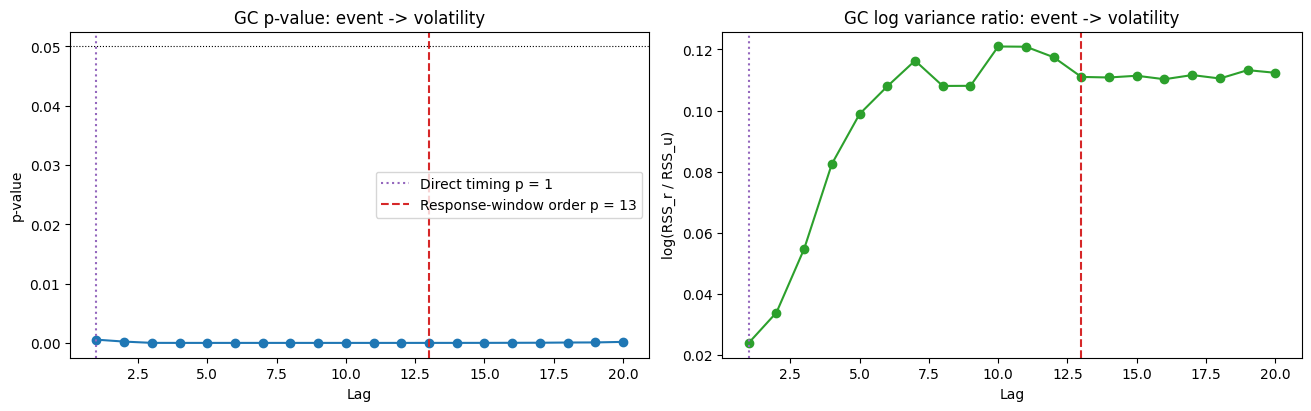

In [7]:
gc_event_to_sigma = granger_results_table(sigma_t, event_t, max_lag)
gc_event_to_sigma['direction'] = 'event -> volatility'
gc_event_to_sigma_p1 = gc_event_to_sigma.loc[gc_event_to_sigma['lag'].eq(direct_timing_lag)].iloc[0]
gc_event_to_sigma_p13 = gc_event_to_sigma.loc[gc_event_to_sigma['lag'].eq(response_window_lag)].iloc[0]
print('Direct one-step timing check (p = 1):')
print(gc_event_to_sigma_p1.to_string())
print(f'Full event-response-window lag order (p = {response_window_lag}):')
print(gc_event_to_sigma_p13.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(gc_event_to_sigma['lag'], gc_event_to_sigma['p_value'], marker='o')
axes[0].axvline(direct_timing_lag, color='tab:purple', linestyle=':', label='Direct timing p = 1')
axes[0].axvline(response_window_lag, color='tab:red', linestyle='--', label=f'Response-window order p = {response_window_lag}')
axes[0].axhline(0.05, color='black', linewidth=0.8, linestyle=':')
axes[0].set(title='GC p-value: event -> volatility', xlabel='Lag', ylabel='p-value')
axes[0].legend()
axes[1].plot(gc_event_to_sigma['lag'], gc_event_to_sigma['log_variance_ratio'], marker='o', color='tab:green')
axes[1].axvline(direct_timing_lag, color='tab:purple', linestyle=':')
axes[1].axvline(response_window_lag, color='tab:red', linestyle='--')
axes[1].set(title='GC log variance ratio: event -> volatility', xlabel='Lag', ylabel='log(RSS_r / RSS_u)')
plt.show()

## 11. Granger results: volatility -> event

Here the binary event indicator is the target. This uses the same linear nested-regression statistic as a predictive diagnostic, not a probability model. The structural generator has no sigma -> E edge, so a reverse result may reflect deterministic periodicity and calendar-phase predictability.

Direct one-step timing check (p = 1):
lag                                     1
n_obs                                 503
rss_restricted                  21.897917
rss_unrestricted                21.891076
f_stat                           0.156245
p_value                          0.692806
residual_df                           500
log_variance_ratio               0.000312
direction             volatility -> event
Full event-response-window lag order (p = 13):
lag                                    13
n_obs                                 491
rss_restricted                  20.244792
rss_unrestricted                19.605432
f_stat                           1.163975
p_value                          0.303267
residual_df                           464
log_variance_ratio               0.032091
direction             volatility -> event


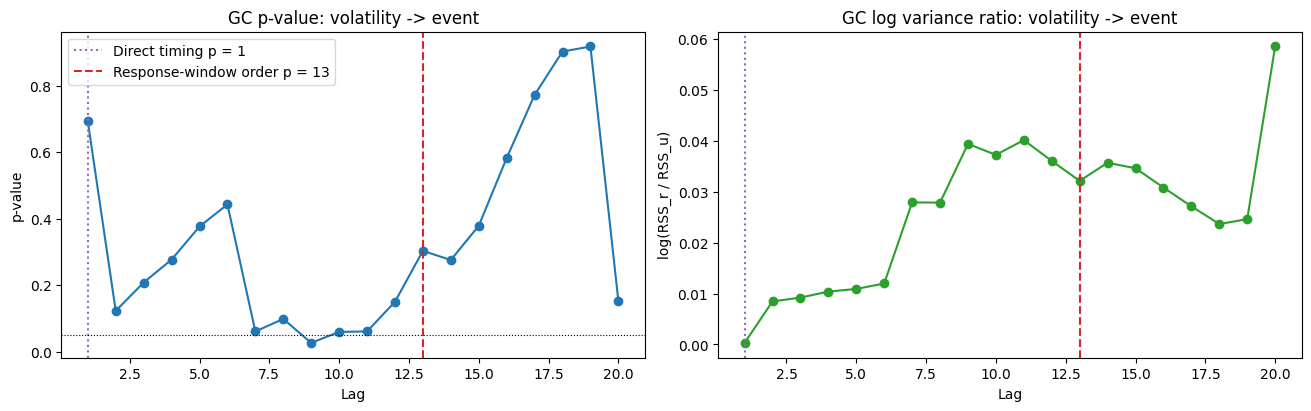

In [8]:
gc_sigma_to_event = granger_results_table(event_t, sigma_t, max_lag)
gc_sigma_to_event['direction'] = 'volatility -> event'
gc_sigma_to_event_p1 = gc_sigma_to_event.loc[gc_sigma_to_event['lag'].eq(direct_timing_lag)].iloc[0]
gc_sigma_to_event_p13 = gc_sigma_to_event.loc[gc_sigma_to_event['lag'].eq(response_window_lag)].iloc[0]
print('Direct one-step timing check (p = 1):')
print(gc_sigma_to_event_p1.to_string())
print(f'Full event-response-window lag order (p = {response_window_lag}):')
print(gc_sigma_to_event_p13.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(gc_sigma_to_event['lag'], gc_sigma_to_event['p_value'], marker='o')
axes[0].axvline(direct_timing_lag, color='tab:purple', linestyle=':', label='Direct timing p = 1')
axes[0].axvline(response_window_lag, color='tab:red', linestyle='--', label=f'Response-window order p = {response_window_lag}')
axes[0].axhline(0.05, color='black', linewidth=0.8, linestyle=':')
axes[0].set(title='GC p-value: volatility -> event', xlabel='Lag', ylabel='p-value')
axes[0].legend()
axes[1].plot(gc_sigma_to_event['lag'], gc_sigma_to_event['log_variance_ratio'], marker='o', color='tab:green')
axes[1].axvline(direct_timing_lag, color='tab:purple', linestyle=':')
axes[1].axvline(response_window_lag, color='tab:red', linestyle='--')
axes[1].set(title='GC log variance ratio: volatility -> event', xlabel='Lag', ylabel='log(RSS_r / RSS_u)')
plt.show()

## 12. Statsmodels Granger cross-check

`grangercausalitytests` tests whether its second column Granger-causes its first. The same column order is therefore used as the manual target-driver tests. The F-statistics and p-values at the primary lag must agree up to numerical tolerance.

In [9]:
def statsmodels_gc_at_lag(target, driver, lag):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        result = grangercausalitytests(np.column_stack([target, driver]), maxlag=[lag], verbose=False)
    f_stat, p_value, residual_df, numerator_df = result[lag][0]['ssr_ftest']
    return {'f_stat': float(f_stat), 'p_value': float(p_value), 'residual_df': float(residual_df), 'numerator_df': float(numerator_df)}


gc_crosscheck_rows = []
for direction, target, driver, manual_table in [
    ('event -> volatility', sigma_t, event_t, gc_event_to_sigma),
    ('volatility -> event', event_t, sigma_t, gc_sigma_to_event),
]:
    for lag in (direct_timing_lag, response_window_lag):
        software_result = statsmodels_gc_at_lag(target, driver, lag)
        manual_result = manual_table.loc[manual_table['lag'].eq(lag)].iloc[0]
        np.testing.assert_allclose(software_result['f_stat'], manual_result['f_stat'], rtol=1e-9, atol=1e-10)
        np.testing.assert_allclose(software_result['p_value'], manual_result['p_value'], rtol=1e-9, atol=1e-12)
        gc_crosscheck_rows.append({
            'direction': direction, 'lag': lag,
            'manual_f_stat': manual_result['f_stat'], 'statsmodels_f_stat': software_result['f_stat'],
            'manual_p_value': manual_result['p_value'], 'statsmodels_p_value': software_result['p_value'],
        })
gc_crosscheck_table = pd.DataFrame(gc_crosscheck_rows)
print(f'Manual and statsmodels tests agree at p = 1 and p = {response_window_lag} in both directions.')
print(gc_crosscheck_table.to_string(index=False))

Manual and statsmodels tests agree at p = 1 and p = 13 in both directions.
          direction  lag  manual_f_stat  statsmodels_f_stat  manual_p_value  statsmodels_p_value
event -> volatility    1      12.094457           12.094457        0.000550             0.000550
event -> volatility   13       4.190183            4.190183        0.000001             0.000001
volatility -> event    1       0.156245            0.156245        0.692806             0.692806
volatility -> event   13       1.163975            1.163975        0.303267             0.303267


## 13. TDMI methodology and lag convention

For integer lag tau, this notebook defines I_tau = I(E_t; sigma_(t+tau)). Positive lags mean the event occurs earlier and volatility occurs later, so they are event-leading lags. Negative lags mean volatility occurs earlier and event occurs later, so they are volatility-leading lags. Zero is contemporaneous.

For each requested bin count, empirical quantile edges are calculated once from the complete `sigma_t` series with `pandas.qcut(..., retbins=True, duplicates='drop')`. The outer edges are replaced by negative and positive infinity. Every lag in that curve then applies the same edges with `pandas.cut`, making TDMI values comparable across lags.

If n(e,b) is the contingency-table count for binary event value e and fixed volatility bin b, and N is the number of aligned pairs, then p(e,b) = n(e,b) / N. The marginals are p(e) = n_e / N and p(b) = n_b / N. The estimator is calculated directly over non-zero cells as I_tau = sum_(e,b) p(e,b) log[p(e,b) / (p(e)p(b))]. Natural logarithms are used, so TDMI is measured in nats.

## 14. TDMI results across positive and negative lags

In [10]:
def tdmi_pairs(event, sigma, lag):
    event = np.asarray(event, dtype=int)
    sigma = np.asarray(sigma, dtype=float)
    if event.ndim != 1 or sigma.ndim != 1 or event.size != sigma.size:
        raise ValueError('event and sigma must be equal-length one-dimensional arrays.')
    if abs(lag) >= event.size:
        raise ValueError('absolute lag must be smaller than the series length.')
    if lag > 0:
        event_pair, sigma_pair = event[:-lag], sigma[lag:]
    elif lag < 0:
        step = abs(lag)
        event_pair, sigma_pair = event[step:], sigma[:-step]
    else:
        event_pair, sigma_pair = event, sigma
    if event_pair.size != sigma_pair.size:
        raise AssertionError('TDMI paired arrays must have equal lengths.')
    return event_pair, sigma_pair


def make_quantile_bin_edges(values, requested_bins):
    if requested_bins < 2:
        raise ValueError('requested_bins must be at least two.')
    _, bin_edges = pd.qcut(
        pd.Series(np.asarray(values, dtype=float)),
        q=requested_bins,
        retbins=True,
        duplicates='drop',
    )
    bin_edges = np.asarray(bin_edges, dtype=float)
    if bin_edges.size < 3:
        raise ValueError('Quantile discretisation produced fewer than two bins.')
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    return bin_edges


def tdmi_from_counts(event_pair, sigma_bin_pair):
    event_pair = np.asarray(event_pair, dtype=int)
    sigma_bin_pair = np.asarray(sigma_bin_pair, dtype=int)
    if event_pair.size != sigma_bin_pair.size:
        raise ValueError('event_pair and sigma_bin_pair must have equal lengths.')
    contingency = pd.crosstab(
        pd.Series(event_pair, name='event'),
        pd.Series(sigma_bin_pair, name='sigma_bin'),
        dropna=False,
    )
    counts = contingency.to_numpy(dtype=float)
    joint_probability = counts / counts.sum()
    event_probability = joint_probability.sum(axis=1, keepdims=True)
    bin_probability = joint_probability.sum(axis=0, keepdims=True)
    independent_probability = event_probability @ bin_probability
    non_zero_cells = joint_probability > 0.0
    mutual_information = np.sum(
        joint_probability[non_zero_cells]
        * np.log(joint_probability[non_zero_cells] / independent_probability[non_zero_cells])
    )
    return float(mutual_information)


def tdmi_at_lag(event, sigma, lag, bin_edges):
    event_pair, sigma_pair = tdmi_pairs(event, sigma, lag)
    sigma_bin_pair = pd.cut(
        pd.Series(sigma_pair), bins=bin_edges, labels=False, include_lowest=True
    )
    if sigma_bin_pair.isna().any():
        raise ValueError('Fixed-edge discretisation produced missing bin assignments.')
    mutual_information = tdmi_from_counts(event_pair, sigma_bin_pair.to_numpy(dtype=int))
    return {
        'lag': lag,
        'n_pairs': event_pair.size,
        'mutual_information': mutual_information,
    }


tdmi_method = {
    'estimator': 'direct_contingency_table',
    'volatility_discretisation': 'fixed_quantile_bins',
    'uses_circular_shift': False,
    'uses_permutation': False,
    'uses_sklearn_mi': False,
}
tdmi_lags = list(range(-tdmi_scan_max_lag, tdmi_scan_max_lag + 1))
primary_quantile_bins = 10
primary_bin_edges = make_quantile_bin_edges(sigma_t, primary_quantile_bins)
primary_bin_edges_snapshot = primary_bin_edges.copy()
tdmi_results = pd.DataFrame([
    tdmi_at_lag(event_t, sigma_t, lag, primary_bin_edges)
    for lag in tdmi_lags
])
tdmi_results['direction'] = np.select(
    [tdmi_results['lag'].lt(0), tdmi_results['lag'].eq(0)],
    ['volatility leads event', 'contemporaneous'],
    default='event leads volatility',
)
assert (tdmi_results['n_pairs'] > 0).all()
assert tdmi_results['n_pairs'].eq(len(event_t) - tdmi_results['lag'].abs()).all()
np.testing.assert_array_equal(primary_bin_edges, primary_bin_edges_snapshot)
tdmi_results.head()

,lag,n_pairs,mutual_information,direction
0,-34,470,0.010405,volatility leads event
1,-33,471,0.005598,volatility leads event
2,-32,472,0.001631,volatility leads event
3,-31,473,0.001623,volatility leads event
4,-30,474,0.004672,volatility leads event


## 15. TDMI observed-lag summary

The largest positive- and negative-lag values are descriptive maxima from this simulated sample. No formal p-values are attached, and a maximum is not interpreted as a statistically significant or true causal delay.

In [11]:
positive_tdmi_peak = tdmi_results.loc[tdmi_results['lag'].gt(0)].nlargest(1, 'mutual_information').iloc[0]
negative_tdmi_peak = tdmi_results.loc[tdmi_results['lag'].lt(0)].nlargest(1, 'mutual_information').iloc[0]
zero_tdmi = tdmi_results.loc[tdmi_results['lag'].eq(0)].iloc[0]
print('Strongest positive-lag TDMI:')
print(positive_tdmi_peak.to_string())
print('Strongest negative-lag TDMI:')
print(negative_tdmi_peak.to_string())
print(f'Zero-lag MI: {zero_tdmi["mutual_information"]:.6f}')

Strongest positive-lag TDMI:
lag                                       26
n_pairs                                  478
mutual_information                  0.011406
direction             event leads volatility
Strongest negative-lag TDMI:
lag                                      -34
n_pairs                                  470
mutual_information                  0.010405
direction             volatility leads event
Zero-lag MI: 0.003156


## 16. Comparison of GC and TDMI

GC tests incremental linear predictability after conditioning on the target's own lagged history. TDMI measures nonlinear lagged dependence without that conditioning. Agreement in direction is useful evidence, but the measures answer different questions and neither is unquestioned structural causality.

In [12]:
gc_summary_rows = []
for direction, table in [
    ('event -> volatility', gc_event_to_sigma),
    ('volatility -> event', gc_sigma_to_event),
]:
    for lag_label, lag in [
        ('direct one-step timing check', direct_timing_lag),
        ('full event-response-window lag order', response_window_lag),
    ]:
        row = table.loc[table['lag'].eq(lag)].iloc[0]
        gc_summary_rows.append({
            'direction': direction,
            'lag_label': lag_label,
            'lag': lag,
            'F-statistic': row['f_stat'],
            'p-value': row['p_value'],
            'log variance ratio': row['log_variance_ratio'],
        })
gc_summary_table = pd.DataFrame(gc_summary_rows)
tdmi_summary_table = pd.DataFrame([{
    'strongest_positive_lag': int(positive_tdmi_peak['lag']),
    'strongest_positive_mi': positive_tdmi_peak['mutual_information'],
    'strongest_negative_lag': int(negative_tdmi_peak['lag']),
    'strongest_negative_mi': negative_tdmi_peak['mutual_information'],
    'zero_lag_mi': zero_tdmi['mutual_information'],
    'primary_bins': primary_quantile_bins,
}])
print('GC summary:')
print(gc_summary_table.to_string(index=False))
print('TDMI summary:')
print(tdmi_summary_table.to_string(index=False))

GC summary:
          direction                            lag_label  lag  F-statistic  p-value  log variance ratio
event -> volatility         direct one-step timing check    1    12.094457 0.000550            0.023901
event -> volatility full event-response-window lag order   13     4.190183 0.000001            0.111002
volatility -> event         direct one-step timing check    1     0.156245 0.692806            0.000312
volatility -> event full event-response-window lag order   13     1.163975 0.303267            0.032091
TDMI summary:
 strongest_positive_lag  strongest_positive_mi  strongest_negative_lag  strongest_negative_mi  zero_lag_mi  primary_bins
                     26               0.011406                     -34               0.010405     0.003156            10


## 17. Interpretation against the known structural graph

The benchmark generator contains E_i -> omega_(i+1) -> sigma_(i+1) and no volatility-to-event edge. A positive-lag TDMI peak or an event-to-volatility GC result is consistent with that graph, not proof of it. Reverse-direction results are retained as a false reverse edge: with deterministic periodic events, they can arise from periodicity-induced predictability rather than a structural sigma -> E effect. Peaks near plus or minus 21 should similarly be interpreted as repeated-cycle structure.

## 19. Volatility-level interpretation

The known structural graph is E_i -> omega_(i+1) -> sigma_(i+1). At p = 1, the event indicator Granger-predicts volatility (F = 12.094457, p = 0.000550, log variance ratio = 0.023901), whereas volatility does not Granger-predict the event indicator (F = 0.156245, p = 0.692806, log variance ratio = 0.000312). This is a clean one-step predictive-direction result, not proof of physical causality.

The code-generated response-window GC summary reports the cumulative model order inherited from `reference_timing`. That order jointly includes all lags through the response window and is not an individual causal delay.

All current peak locations and values are reported by the code-generated dynamic peak tables. They are descriptive sample maxima without formal p-values and are not estimates of a true causal delay.

Bin-sensitivity peak locations are reported by the code-generated dynamic sensitivity table below.

GC asks whether lagged driver values improve linear prediction beyond the target's own history. TDMI measures general lagged dependence and does not condition on that history, so the two methods do not answer the same question. Their agreement or disagreement is informative but does not establish structural causality.

## 18. Raw-volatility TDMI sensitivity and mechanical checks

The raw-volatility sensitivity curve and its prerequisite mechanical checks are calculated before the volatility-change analysis.


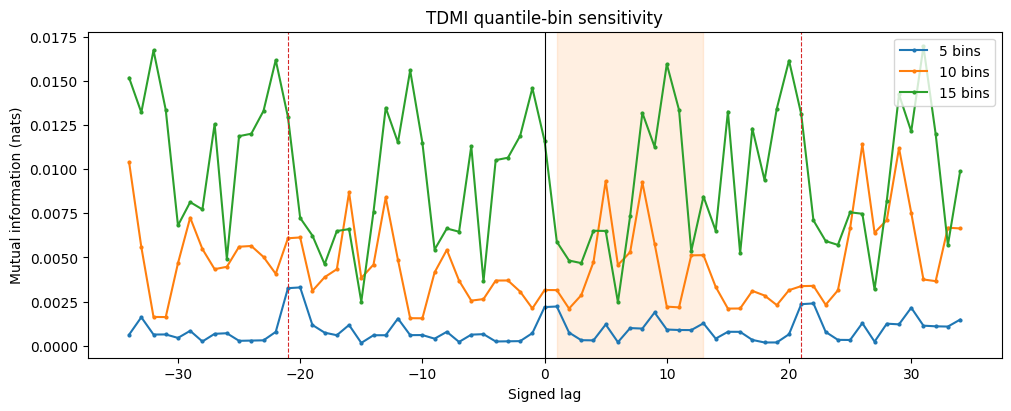

notebook_00_loaded: passed
n_equals_1: passed
event_period_matches_reference_timing: passed
analysis_alignment: passed
binary_event_and_no_missing_primary_values: passed
historical_gc_lag_matrices: passed
gc_rss_and_residual_df_checks: passed
manual_statsmodels_gc_agreement_p1_and_response_window_order: passed
tdmi_pair_lengths_and_lag_convention: passed
fixed_bin_edges_reused_within_each_curve: passed
tdmi_timing_unit_test: passed
declared_tdmi_method_configuration: passed
simulator_values_unchanged: passed
quantile_bin_sensitivity_completed: passed
Quantile-bin sensitivity peak lags:
 quantile_bins  strongest_positive_lag  strongest_negative_lag  overall_maximum_lag
             5                      22                     -20                  -20
            10                      26                     -34                   26
            15                      31                     -32                   31
Exact peak locations identical across bins: False
Raw-volatility TDMI c

In [13]:
synthetic_rng = np.random.default_rng(1701)
synthetic_event = synthetic_rng.integers(0, 2, size=120)
synthetic_delay = 4
synthetic_sigma = np.zeros_like(synthetic_event, dtype=float)
synthetic_sigma[synthetic_delay:] = synthetic_event[:-synthetic_delay]
synthetic_sigma += synthetic_rng.normal(scale=1e-4, size=synthetic_sigma.size)
synthetic_bin_edges = make_quantile_bin_edges(synthetic_sigma, primary_quantile_bins)
synthetic_tdmi = pd.DataFrame([
    tdmi_at_lag(synthetic_event, synthetic_sigma, lag, synthetic_bin_edges)
    for lag in range(-10, 11)
])
assert int(synthetic_tdmi.loc[synthetic_tdmi['mutual_information'].idxmax(), 'lag']) == synthetic_delay

sensitivity_rows = []
sensitivity_edges = {
    quantile_bins: make_quantile_bin_edges(sigma_t, quantile_bins)
    for quantile_bins in (5, 10, 15)
}
sensitivity_edge_snapshots = {
    quantile_bins: edges.copy() for quantile_bins, edges in sensitivity_edges.items()
}
for quantile_bins in (5, 10, 15):
    fixed_edges = sensitivity_edges[quantile_bins]
    curve = [tdmi_at_lag(event_t, sigma_t, lag, fixed_edges) for lag in tdmi_lags]
    sensitivity_rows.extend({**row, 'quantile_bins': quantile_bins} for row in curve)
sensitivity_table = pd.DataFrame(sensitivity_rows)

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
for quantile_bins, subset in sensitivity_table.groupby('quantile_bins'):
    axis.plot(subset['lag'], subset['mutual_information'], marker='o', markersize=2, label=f'{quantile_bins} bins')
axis.axvline(0, color='black', linewidth=0.8)
axis.axvspan(response_state_lag_start, response_state_lag_end, color='tab:orange', alpha=0.12)
axis.axvline(event_period_steps, color='tab:red', linestyle='--', linewidth=0.8)
axis.axvline(-event_period_steps, color='tab:red', linestyle='--', linewidth=0.8)
axis.set(title='TDMI quantile-bin sensitivity', xlabel='Signed lag', ylabel='Mutual information (nats)')
axis.legend()
plt.show()

sensitivity_peak_rows = []
for quantile_bins, subset in sensitivity_table.groupby('quantile_bins'):
    positive_peak = subset.loc[subset['lag'].gt(0)].nlargest(1, 'mutual_information').iloc[0]
    negative_peak = subset.loc[subset['lag'].lt(0)].nlargest(1, 'mutual_information').iloc[0]
    overall_peak = subset.nlargest(1, 'mutual_information').iloc[0]
    sensitivity_peak_rows.append({
        'quantile_bins': quantile_bins,
        'strongest_positive_lag': int(positive_peak['lag']),
        'strongest_negative_lag': int(negative_peak['lag']),
        'overall_maximum_lag': int(overall_peak['lag']),
    })
sensitivity_peak_table = pd.DataFrame(sensitivity_peak_rows)
sensitivity_pivot = sensitivity_table.pivot(index='lag', columns='quantile_bins', values='mutual_information')
sensitivity_correlations = sensitivity_pivot.corr()

def mean_pairwise_curve_correlation(correlation_table):
    correlation_array = correlation_table.to_numpy(dtype=float)
    upper_triangle = correlation_array[np.triu_indices_from(correlation_array, k=1)]
    return float(upper_triangle.mean())

level_sensitivity_pivot = sensitivity_pivot
level_sensitivity_correlations = sensitivity_correlations
level_mean_curve_correlation = mean_pairwise_curve_correlation(level_sensitivity_correlations)
for quantile_bins, edges in sensitivity_edges.items():
    np.testing.assert_array_equal(edges, sensitivity_edge_snapshots[quantile_bins])
peak_locations_match = bool(
    sensitivity_peak_table[['strongest_positive_lag', 'strongest_negative_lag', 'overall_maximum_lag']]
    .nunique().eq(1).all()
)
assert tdmi_method['estimator'] == 'direct_contingency_table'
assert tdmi_method['volatility_discretisation'] == 'fixed_quantile_bins'
assert tdmi_method['uses_circular_shift'] is False
assert tdmi_method['uses_permutation'] is False
assert tdmi_method['uses_sklearn_mi'] is False
assert len(gc_crosscheck_table) == 4
assert (gc_event_to_sigma['rss_unrestricted'] <= gc_event_to_sigma['rss_restricted'] + 1e-10).all()
assert (gc_sigma_to_event['rss_unrestricted'] <= gc_sigma_to_event['rss_restricted'] + 1e-10).all()
assert (gc_event_to_sigma['residual_df'] > 0).all()
assert (gc_sigma_to_event['residual_df'] > 0).all()
pd.testing.assert_frame_equal(states, states_snapshot)
pd.testing.assert_frame_equal(transitions, transitions_snapshot)

validation_summary = {
    'notebook_00_loaded': 'passed',
    'n_equals_1': 'passed',
    'event_period_matches_reference_timing': 'passed',
    'analysis_alignment': 'passed',
    'binary_event_and_no_missing_primary_values': 'passed',
    'historical_gc_lag_matrices': 'passed',
    'gc_rss_and_residual_df_checks': 'passed',
    'manual_statsmodels_gc_agreement_p1_and_response_window_order': 'passed',
    'tdmi_pair_lengths_and_lag_convention': 'passed',
    'fixed_bin_edges_reused_within_each_curve': 'passed',
    'tdmi_timing_unit_test': 'passed',
    'declared_tdmi_method_configuration': 'passed',
    'simulator_values_unchanged': 'passed',
    'quantile_bin_sensitivity_completed': 'passed',
}
for check, outcome in validation_summary.items():
    print(f'{check}: {outcome}')
print('Quantile-bin sensitivity peak lags:')
print(sensitivity_peak_table.to_string(index=False))
print(f'Exact peak locations identical across bins: {peak_locations_match}')
print('Raw-volatility TDMI curve correlation matrix:')
print(level_sensitivity_correlations.to_string())
print(f'Mean raw-volatility pairwise curve correlation: {level_mean_curve_correlation:.6f}')

## 20. Complementary state-indexed volatility-change analysis

This addition retains the raw-volatility analysis above and studies delta_sigma_t = sigma_t - sigma_(t-1). With the simulator timing E_(t-1) -> sigma_t, a lag-one predictive relation in the aligned change table represents E_(t-1) -> delta_sigma_t. This is complementary analysis, not a replacement for the persistent volatility-level target.

In [14]:
raw_gc_summary_snapshot = gc_summary_table.copy(deep=True)
raw_tdmi_results_snapshot = tdmi_results.copy(deep=True)

sigma_values = states['sigma'].to_numpy()
event_values = transitions['event'].to_numpy()
change_analysis = pd.DataFrame({
    't': states['t'].iloc[1:-1].to_numpy(),
    'delta_sigma_t': sigma_values[1:-1] - sigma_values[:-2],
    'event_t': event_values[1:],
})

assert len(change_analysis['t']) == len(change_analysis['delta_sigma_t']) == len(change_analysis['event_t'])
np.testing.assert_allclose(change_analysis['delta_sigma_t'], sigma_values[1:-1] - sigma_values[:-2])
assert set(change_analysis['event_t'].unique()).issubset({0, 1})
assert change_analysis.notna().all().all()

delta_sigma_t = change_analysis['delta_sigma_t'].to_numpy()
change_event_t = change_analysis['event_t'].to_numpy(dtype=float)
print(f'Change-analysis rows: {len(change_analysis)}')
print(f'Change-analysis event fraction: {change_analysis["event_t"].mean():.6f}')

Change-analysis rows: 503
Change-analysis event fraction: 0.045726


## 21. Granger causality for volatility changes

The existing manual nested-regression helper and statsmodels cross-check helper are reused without restating their derivation. Lag p = 1 is the direct one-step timing check; the code-generated response-window order is cumulative, not a causal delay.

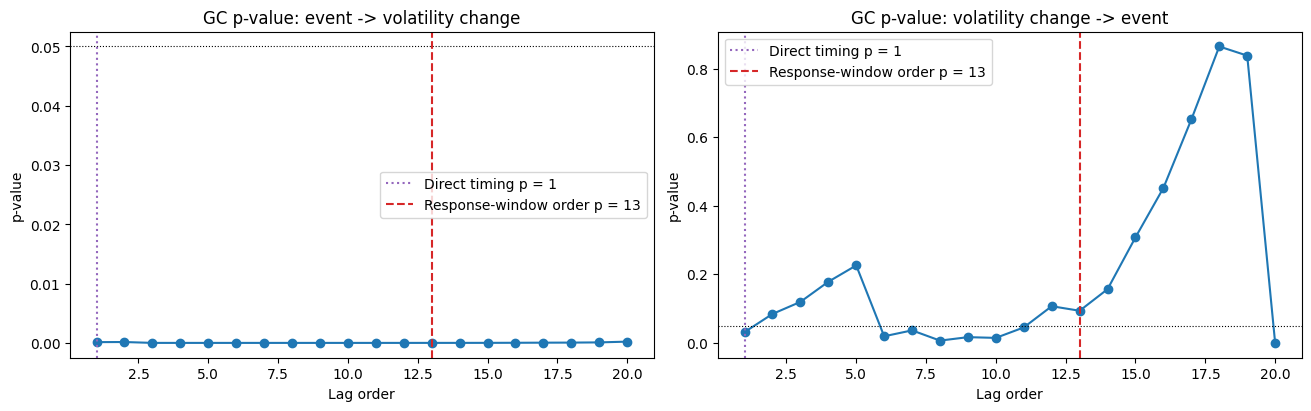

                    target_type                  direction                            lag_label  lag  F-statistic  p-value  log variance ratio
volatility change delta_sigma_t event -> volatility change         direct one-step timing check    1    14.862315 0.000131            0.029349
volatility change delta_sigma_t event -> volatility change full event-response-window lag order   13     4.093560 0.000002            0.108799
volatility change delta_sigma_t volatility change -> event         direct one-step timing check    1     4.655207 0.031436            0.009286
volatility change delta_sigma_t volatility change -> event full event-response-window lag order   13     1.558172 0.093732            0.042820


In [15]:
change_gc_event_to_delta = granger_results_table(delta_sigma_t, change_event_t, max_lag)
change_gc_event_to_delta['direction'] = 'event -> volatility change'
change_gc_delta_to_event = granger_results_table(change_event_t, delta_sigma_t, max_lag)
change_gc_delta_to_event['direction'] = 'volatility change -> event'

change_gc_crosscheck_rows = []
for direction, target, driver, result_table in [
    ('event -> volatility change', delta_sigma_t, change_event_t, change_gc_event_to_delta),
    ('volatility change -> event', change_event_t, delta_sigma_t, change_gc_delta_to_event),
]:
    for lag in (direct_timing_lag, response_window_lag):
        manual_result = result_table.loc[result_table['lag'].eq(lag)].iloc[0]
        software_result = statsmodels_gc_at_lag(target, driver, lag)
        np.testing.assert_allclose(manual_result['f_stat'], software_result['f_stat'], rtol=1e-9, atol=1e-10)
        np.testing.assert_allclose(manual_result['p_value'], software_result['p_value'], rtol=1e-9, atol=1e-12)
        change_gc_crosscheck_rows.append({
            'direction': direction, 'lag': lag,
            'manual_f_stat': manual_result['f_stat'], 'statsmodels_f_stat': software_result['f_stat'],
            'manual_p_value': manual_result['p_value'], 'statsmodels_p_value': software_result['p_value'],
        })
change_gc_crosscheck_table = pd.DataFrame(change_gc_crosscheck_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for axis, result_table, title in [
    (axes[0], change_gc_event_to_delta, 'GC p-value: event -> volatility change'),
    (axes[1], change_gc_delta_to_event, 'GC p-value: volatility change -> event'),
]:
    axis.plot(result_table['lag'], result_table['p_value'], marker='o')
    axis.axhline(0.05, color='black', linewidth=0.8, linestyle=':')
    axis.axvline(direct_timing_lag, color='tab:purple', linestyle=':', label='Direct timing p = 1')
    axis.axvline(response_window_lag, color='tab:red', linestyle='--', label=f'Response-window order p = {response_window_lag}')
    axis.set(title=title, xlabel='Lag order', ylabel='p-value')
    axis.legend()
plt.show()

change_gc_summary_rows = []
for direction, result_table in [
    ('event -> volatility change', change_gc_event_to_delta),
    ('volatility change -> event', change_gc_delta_to_event),
]:
    for lag_label, lag in [
        ('direct one-step timing check', direct_timing_lag),
        ('full event-response-window lag order', response_window_lag),
    ]:
        row = result_table.loc[result_table['lag'].eq(lag)].iloc[0]
        change_gc_summary_rows.append({
            'target_type': 'volatility change delta_sigma_t',
            'direction': direction,
            'lag_label': lag_label,
            'lag': lag,
            'F-statistic': row['f_stat'],
            'p-value': row['p_value'],
            'log variance ratio': row['log_variance_ratio'],
        })
change_gc_summary_table = pd.DataFrame(change_gc_summary_rows)
print(change_gc_summary_table.to_string(index=False))

## 22. TDMI for volatility changes and level-versus-change comparison

The existing signed-lag alignment and direct contingency-table TDMI calculation are reused. Fixed bin edges are calculated once from the complete change series for each bin count. TDMI reports lagged dependence without conditioning on the target's own history, so it is compared with, rather than equated to, Granger prediction.

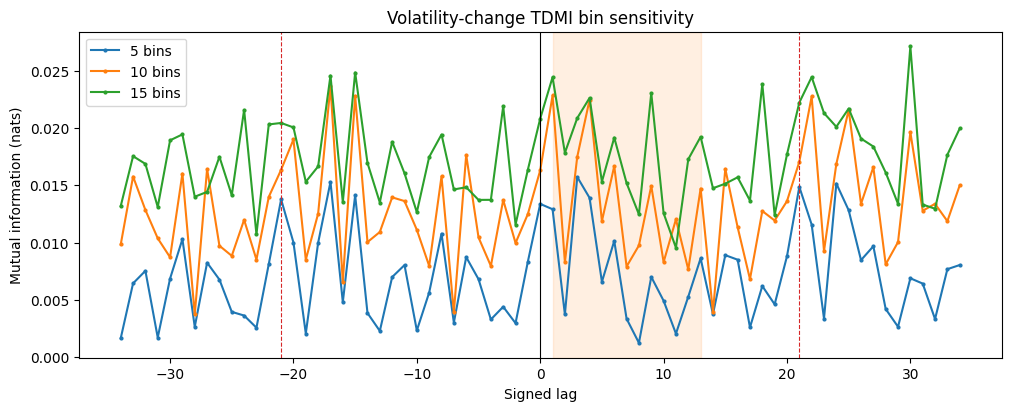

Change TDMI summary:
 strongest_positive_lag  strongest_positive_mi  strongest_negative_lag  strongest_negative_mi  zero_lag_mi
                      1               0.022854                     -17               0.023674     0.016311
Change TDMI bin peaks:
 quantile_bins  strongest_positive_lag  strongest_negative_lag  overall_maximum_lag
             5                       3                     -17                    3
            10                       1                     -17                  -17
            15                      30                     -15                   30
Level-versus-change comparison:
                         target  event_to_target_p1_F  event_to_target_p1_p  event_to_target_p13_F  event_to_target_p13_p  reverse_p1_F  reverse_p1_p  strongest_positive_tdmi_lag  strongest_negative_tdmi_lag  zero_lag_tdmi  exact_peak_location_stability  mean_pairwise_tdmi_curve_correlation
         raw volatility sigma_t             12.094457              0.000550       

In [16]:
change_tdmi_lags = list(range(-tdmi_scan_max_lag, tdmi_scan_max_lag + 1))
change_primary_bin_edges = make_quantile_bin_edges(delta_sigma_t, primary_quantile_bins)
change_primary_bin_edges_snapshot = change_primary_bin_edges.copy()
change_tdmi_results = pd.DataFrame([
    tdmi_at_lag(change_event_t, delta_sigma_t, lag, change_primary_bin_edges)
    for lag in change_tdmi_lags
])
change_tdmi_results['direction_label'] = np.select(
    [change_tdmi_results['lag'].lt(0), change_tdmi_results['lag'].eq(0)],
    ['volatility change leads event', 'contemporaneous'],
    default='event leads volatility change',
)
assert change_tdmi_results['n_pairs'].eq(len(change_event_t) - change_tdmi_results['lag'].abs()).all()
np.testing.assert_array_equal(change_primary_bin_edges, change_primary_bin_edges_snapshot)

change_positive_tdmi_peak = change_tdmi_results.loc[change_tdmi_results['lag'].gt(0)].nlargest(1, 'mutual_information').iloc[0]
change_negative_tdmi_peak = change_tdmi_results.loc[change_tdmi_results['lag'].lt(0)].nlargest(1, 'mutual_information').iloc[0]
change_zero_tdmi = change_tdmi_results.loc[change_tdmi_results['lag'].eq(0)].iloc[0]

change_sensitivity_rows = []
change_sensitivity_edges = {quantile_bins: make_quantile_bin_edges(delta_sigma_t, quantile_bins) for quantile_bins in (5, 10, 15)}
change_sensitivity_edge_snapshots = {quantile_bins: edges.copy() for quantile_bins, edges in change_sensitivity_edges.items()}
for quantile_bins, fixed_edges in change_sensitivity_edges.items():
    curve = [tdmi_at_lag(change_event_t, delta_sigma_t, lag, fixed_edges) for lag in change_tdmi_lags]
    change_sensitivity_rows.extend({**row, 'quantile_bins': quantile_bins} for row in curve)
change_sensitivity_table = pd.DataFrame(change_sensitivity_rows)

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
for quantile_bins, subset in change_sensitivity_table.groupby('quantile_bins'):
    axis.plot(subset['lag'], subset['mutual_information'], marker='o', markersize=2, label=f'{quantile_bins} bins')
axis.axvline(0, color='black', linewidth=0.8)
axis.axvspan(response_state_lag_start, response_state_lag_end, color='tab:orange', alpha=0.12)
axis.axvline(event_period_steps, color='tab:red', linestyle='--', linewidth=0.8)
axis.axvline(-event_period_steps, color='tab:red', linestyle='--', linewidth=0.8)
axis.set(title='Volatility-change TDMI bin sensitivity', xlabel='Signed lag', ylabel='Mutual information (nats)')
axis.legend()
plt.show()

change_sensitivity_peak_rows = []
for quantile_bins, subset in change_sensitivity_table.groupby('quantile_bins'):
    positive_peak = subset.loc[subset['lag'].gt(0)].nlargest(1, 'mutual_information').iloc[0]
    negative_peak = subset.loc[subset['lag'].lt(0)].nlargest(1, 'mutual_information').iloc[0]
    overall_peak = subset.nlargest(1, 'mutual_information').iloc[0]
    change_sensitivity_peak_rows.append({'quantile_bins': quantile_bins, 'strongest_positive_lag': int(positive_peak['lag']), 'strongest_negative_lag': int(negative_peak['lag']), 'overall_maximum_lag': int(overall_peak['lag'])})
change_sensitivity_peak_table = pd.DataFrame(change_sensitivity_peak_rows)
change_peak_locations_match = bool(change_sensitivity_peak_table[['strongest_positive_lag', 'strongest_negative_lag', 'overall_maximum_lag']].nunique().eq(1).all())
change_sensitivity_pivot = change_sensitivity_table.pivot(index='lag', columns='quantile_bins', values='mutual_information')
change_sensitivity_correlations = change_sensitivity_pivot.corr()
change_mean_curve_correlation = mean_pairwise_curve_correlation(change_sensitivity_correlations)
change_tdmi_curve_more_stable = change_mean_curve_correlation > level_mean_curve_correlation

level_vs_change_table = pd.DataFrame([
    {'target': 'raw volatility sigma_t', 'event_to_target_p1_F': gc_event_to_sigma_p1['f_stat'], 'event_to_target_p1_p': gc_event_to_sigma_p1['p_value'], 'event_to_target_p13_F': gc_event_to_sigma_p13['f_stat'], 'event_to_target_p13_p': gc_event_to_sigma_p13['p_value'], 'reverse_p1_F': gc_sigma_to_event_p1['f_stat'], 'reverse_p1_p': gc_sigma_to_event_p1['p_value'], 'strongest_positive_tdmi_lag': int(positive_tdmi_peak['lag']), 'strongest_negative_tdmi_lag': int(negative_tdmi_peak['lag']), 'zero_lag_tdmi': zero_tdmi['mutual_information'], 'exact_peak_location_stability': peak_locations_match, 'mean_pairwise_tdmi_curve_correlation': level_mean_curve_correlation},
    {'target': 'volatility change delta_sigma_t', 'event_to_target_p1_F': change_gc_event_to_delta.loc[change_gc_event_to_delta['lag'].eq(1), 'f_stat'].iloc[0], 'event_to_target_p1_p': change_gc_event_to_delta.loc[change_gc_event_to_delta['lag'].eq(1), 'p_value'].iloc[0], 'event_to_target_p13_F': change_gc_event_to_delta.loc[change_gc_event_to_delta['lag'].eq(13), 'f_stat'].iloc[0], 'event_to_target_p13_p': change_gc_event_to_delta.loc[change_gc_event_to_delta['lag'].eq(13), 'p_value'].iloc[0], 'reverse_p1_F': change_gc_delta_to_event.loc[change_gc_delta_to_event['lag'].eq(1), 'f_stat'].iloc[0], 'reverse_p1_p': change_gc_delta_to_event.loc[change_gc_delta_to_event['lag'].eq(1), 'p_value'].iloc[0], 'strongest_positive_tdmi_lag': int(change_positive_tdmi_peak['lag']), 'strongest_negative_tdmi_lag': int(change_negative_tdmi_peak['lag']), 'zero_lag_tdmi': change_zero_tdmi['mutual_information'], 'exact_peak_location_stability': change_peak_locations_match, 'mean_pairwise_tdmi_curve_correlation': change_mean_curve_correlation},
])

for quantile_bins, edges in change_sensitivity_edges.items():
    np.testing.assert_array_equal(edges, change_sensitivity_edge_snapshots[quantile_bins])
assert level_sensitivity_correlations.shape == (3, 3)
assert change_sensitivity_correlations.shape == (3, 3)
np.testing.assert_allclose(np.diag(level_sensitivity_correlations), 1.0, atol=1e-12)
np.testing.assert_allclose(np.diag(change_sensitivity_correlations), 1.0, atol=1e-12)
assert np.isfinite(level_mean_curve_correlation)
assert np.isfinite(change_mean_curve_correlation)
assert change_tdmi_curve_more_stable == (change_mean_curve_correlation > level_mean_curve_correlation)
assert len(change_gc_crosscheck_table) == 4
assert (change_gc_event_to_delta['rss_unrestricted'] <= change_gc_event_to_delta['rss_restricted'] + 1e-10).all()
assert (change_gc_delta_to_event['rss_unrestricted'] <= change_gc_delta_to_event['rss_restricted'] + 1e-10).all()
assert (change_gc_event_to_delta['residual_df'] > 0).all()
assert (change_gc_delta_to_event['residual_df'] > 0).all()
pd.testing.assert_frame_equal(states, states_snapshot)
pd.testing.assert_frame_equal(transitions, transitions_snapshot)
pd.testing.assert_frame_equal(gc_summary_table, raw_gc_summary_snapshot)
pd.testing.assert_frame_equal(tdmi_results, raw_tdmi_results_snapshot)
assert all(outcome == 'passed' for outcome in validation_summary.values())

change_validation_summary = {'change_table_alignment': 'passed', 'change_gc_manual_statsmodels_agreement': 'passed', 'change_tdmi_fixed_edges_and_pair_lengths': 'passed', 'tdmi_curve_stability_metrics': 'passed', 'raw_results_and_simulated_path_unchanged': 'passed', 'existing_validation_checks_remain_passed': 'passed'}
print('Change TDMI summary:')
print(pd.DataFrame([{'strongest_positive_lag': int(change_positive_tdmi_peak['lag']), 'strongest_positive_mi': change_positive_tdmi_peak['mutual_information'], 'strongest_negative_lag': int(change_negative_tdmi_peak['lag']), 'strongest_negative_mi': change_negative_tdmi_peak['mutual_information'], 'zero_lag_mi': change_zero_tdmi['mutual_information']}]).to_string(index=False))
print('Change TDMI bin peaks:')
print(change_sensitivity_peak_table.to_string(index=False))
print('Level-versus-change comparison:')
print(level_vs_change_table.to_string(index=False))
print(f'Exact peak locations identical across bins (raw volatility): {peak_locations_match}')
print(f'Exact peak locations identical across bins (volatility change): {change_peak_locations_match}')
print('Raw-volatility TDMI curve correlation matrix:')
print(level_sensitivity_correlations.to_string())
print('Volatility-change TDMI curve correlation matrix:')
print(change_sensitivity_correlations.to_string())
print(f'Mean raw-volatility pairwise curve correlation: {level_mean_curve_correlation:.6f}')
print(f'Mean volatility-change pairwise curve correlation: {change_mean_curve_correlation:.6f}')
print(f'Broad TDMI curve more stable across bins: {change_tdmi_curve_more_stable}')
for check, outcome in change_validation_summary.items():
    print(f'{check}: {outcome}')

## Dynamic TDMI windows and peak summaries

Direct-response peaks are reported separately from first-cycle and unrestricted global peaks. A peak outside the direct window is not a uniquely identified causal delay; its folded phase is a periodic-alias diagnostic only.


,peak_type,minimum_lag,maximum_lag,peak_lag,peak_mutual_information,n_pairs_at_peak,target,cycle_equivalent_phase,boundary_limited,interpretation
0,global positive,1,34,26,0.011406,478,raw volatility,5.0,False,next-cycle or periodic-alias candidate
1,direct response,1,13,5,0.009329,499,raw volatility,NaN,False,direct response candidate
2,first event cycle,1,21,5,0.009329,499,raw volatility,NaN,False,pre-next-event-cycle dependence
3,global negative,-34,-1,-34,0.010405,470,raw volatility,8.0,True,reverse or periodic-phase dependence
4,contemporaneous,0,0,0,0.003156,504,raw volatility,NaN,False,contemporaneous dependence


,peak_type,minimum_lag,maximum_lag,peak_lag,peak_mutual_information,n_pairs_at_peak,target,cycle_equivalent_phase,boundary_limited,interpretation
0,global positive,1,34,1,0.022854,502,volatility change,1.0,False,next-cycle or periodic-alias candidate
1,direct response,1,13,1,0.022854,502,volatility change,NaN,False,direct response candidate
2,first event cycle,1,21,1,0.022854,502,volatility change,NaN,False,pre-next-event-cycle dependence
3,global negative,-34,-1,-17,0.023674,486,volatility change,4.0,False,reverse or periodic-phase dependence
4,contemporaneous,0,0,0,0.016311,503,volatility change,NaN,False,contemporaneous dependence


Caution (raw volatility, global negative): the unrestricted global maximum is scan-boundary-limited and may move when the scan range is extended.
raw volatility direct exact stability: False ; first-cycle exact stability: False


,quantile_bins,direct_response_peak_lag,direct_response_peak_MI,first_cycle_peak_lag,first_cycle_peak_MI,global_positive_peak_lag,global_negative_peak_lag,overall_global_maximum_lag
0,5,1,0.002223,21,0.002354,22,-20,-20
1,10,5,0.009329,5,0.009329,26,-34,26
2,15,10,0.015953,20,0.016155,31,-32,31


volatility change direct exact stability: False ; first-cycle exact stability: False


,quantile_bins,direct_response_peak_lag,direct_response_peak_MI,first_cycle_peak_lag,first_cycle_peak_MI,global_positive_peak_lag,global_negative_peak_lag,overall_global_maximum_lag
0,5,3,0.015729,3,0.015729,3,-17,3
1,10,1,0.022854,1,0.022854,1,-17,-17
2,15,1,0.024451,1,0.024451,30,-15,30


Broad curve-shape stability remains the existing complete-curve correlation analysis, distinct from exact peak-location stability.


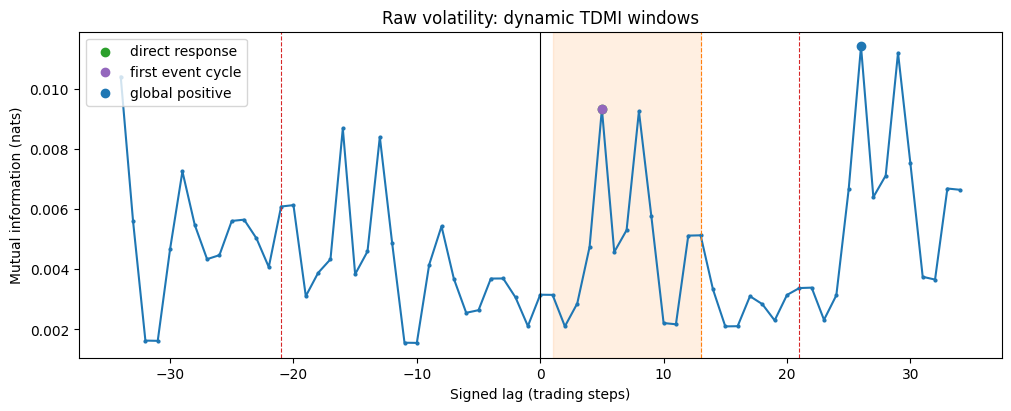

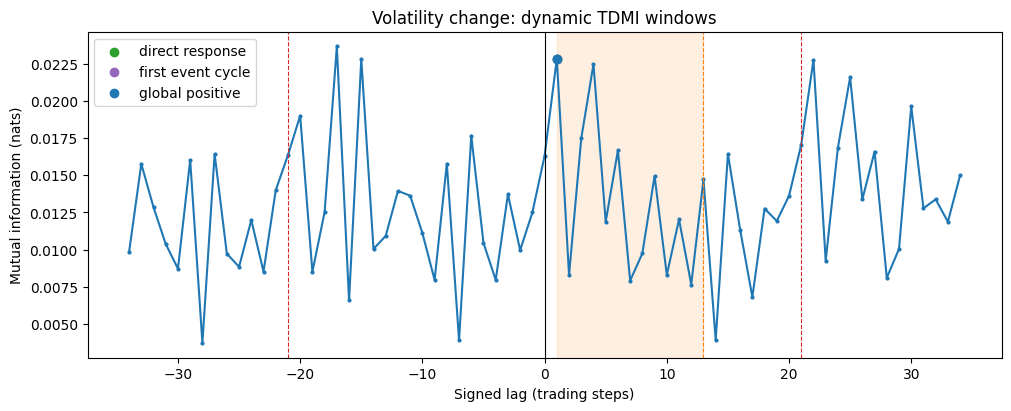

Derived TDMI scan: -34 to +34; GC response-window order: 13.


In [17]:
def tdmi_peak_in_window(tdmi_table, minimum_lag, maximum_lag, label):
    window = tdmi_table.loc[tdmi_table['lag'].between(minimum_lag, maximum_lag, inclusive='both')]
    if window.empty:
        raise ValueError(f'No TDMI observations available for window: {label}')
    peak = window.nlargest(1, 'mutual_information').iloc[0]
    return {'peak_type': label, 'minimum_lag': minimum_lag, 'maximum_lag': maximum_lag, 'peak_lag': int(peak['lag']), 'peak_mutual_information': float(peak['mutual_information']), 'n_pairs_at_peak': int(peak['n_pairs'])}

def fold_lag_to_event_phase(lag, period_steps):
    half_period = period_steps // 2
    return ((int(lag) + half_period) % period_steps) - half_period

def make_peak_summary(table, target):
    rows = [
        tdmi_peak_in_window(table, 1, tdmi_scan_max_lag, 'global positive'),
        tdmi_peak_in_window(table, response_state_lag_start, response_state_lag_end, 'direct response'),
        tdmi_peak_in_window(table, first_cycle_lag_start, first_cycle_lag_end, 'first event cycle'),
        tdmi_peak_in_window(table, -tdmi_scan_max_lag, -1, 'global negative'),
    ]
    zero = table.loc[table['lag'].eq(0)].iloc[0]
    rows.append({'peak_type': 'contemporaneous', 'minimum_lag': 0, 'maximum_lag': 0, 'peak_lag': 0, 'peak_mutual_information': float(zero['mutual_information']), 'n_pairs_at_peak': int(zero['n_pairs'])})
    result = pd.DataFrame(rows)
    result['target'] = target
    result['cycle_equivalent_phase'] = np.where(result['peak_type'].isin(['global positive', 'global negative']), result['peak_lag'].map(lambda x: fold_lag_to_event_phase(x, event_period_steps)), np.nan)
    result['boundary_limited'] = np.select(
        [
            result['peak_type'].eq('global positive'),
            result['peak_type'].eq('global negative'),
        ],
        [
            result['peak_lag'].eq(tdmi_scan_max_lag),
            result['peak_lag'].eq(-tdmi_scan_max_lag),
        ],
        default=False,
    )
    result['interpretation'] = np.select([result['peak_type'].eq('direct response'), result['peak_type'].eq('first event cycle'), result['peak_type'].eq('global positive'), result['peak_type'].eq('global negative')], ['direct response candidate', 'pre-next-event-cycle dependence', 'next-cycle or periodic-alias candidate', 'reverse or periodic-phase dependence'], default='contemporaneous dependence')
    return result

raw_peak_summary = make_peak_summary(tdmi_results, 'raw volatility')
change_peak_summary = make_peak_summary(change_tdmi_results, 'volatility change')
for summary in [raw_peak_summary, change_peak_summary]:
    assert ((summary['peak_lag'] >= summary['minimum_lag']) & (summary['peak_lag'] <= summary['maximum_lag'])).all()
display(raw_peak_summary)
display(change_peak_summary)
for target, summary in [('raw volatility', raw_peak_summary), ('volatility change', change_peak_summary)]:
    for _, peak in summary.loc[summary['peak_type'].isin(['global positive', 'global negative']) & summary['boundary_limited']].iterrows():
        print(f"Caution ({target}, {peak['peak_type']}): the unrestricted global maximum is scan-boundary-limited and may move when the scan range is extended.")

def sensitivity_window_summary(table):
    rows=[]
    for bins, subset in table.groupby('quantile_bins'):
        direct=tdmi_peak_in_window(subset, response_state_lag_start, response_state_lag_end, 'direct response')
        cycle=tdmi_peak_in_window(subset, first_cycle_lag_start, first_cycle_lag_end, 'first event cycle')
        positive=tdmi_peak_in_window(subset, 1, tdmi_scan_max_lag, 'global positive')
        negative=tdmi_peak_in_window(subset, -tdmi_scan_max_lag, -1, 'global negative')
        overall=subset.nlargest(1, 'mutual_information').iloc[0]
        rows.append({'quantile_bins': bins, 'direct_response_peak_lag': direct['peak_lag'], 'direct_response_peak_MI': direct['peak_mutual_information'], 'first_cycle_peak_lag': cycle['peak_lag'], 'first_cycle_peak_MI': cycle['peak_mutual_information'], 'global_positive_peak_lag': positive['peak_lag'], 'global_negative_peak_lag': negative['peak_lag'], 'overall_global_maximum_lag': int(overall['lag'])})
    return pd.DataFrame(rows)
raw_sensitivity_windows=sensitivity_window_summary(sensitivity_table)
change_sensitivity_windows=sensitivity_window_summary(change_sensitivity_table)
for name, table in [('raw volatility', raw_sensitivity_windows), ('volatility change', change_sensitivity_windows)]:
    print(name, 'direct exact stability:', table['direct_response_peak_lag'].nunique()==1, '; first-cycle exact stability:', table['first_cycle_peak_lag'].nunique()==1)
    display(table)
print('Broad curve-shape stability remains the existing complete-curve correlation analysis, distinct from exact peak-location stability.')

for target, table, summary in [('Raw volatility', tdmi_results, raw_peak_summary), ('Volatility change', change_tdmi_results, change_peak_summary)]:
    fig, axis = plt.subplots(figsize=(10,4), constrained_layout=True)
    axis.plot(table['lag'], table['mutual_information'], marker='o', markersize=2)
    axis.axvline(0, color='black', linewidth=.8)
    axis.axvspan(response_state_lag_start, response_state_lag_end, color='tab:orange', alpha=.12)
    axis.axvline(response_state_lag_end, color='tab:orange', linestyle='--', linewidth=.8)
    axis.axvline(event_period_steps, color='tab:red', linestyle='--', linewidth=.8)
    axis.axvline(-event_period_steps, color='tab:red', linestyle='--', linewidth=.8)
    for kind, color in [('direct response','tab:green'),('first event cycle','tab:purple'),('global positive','tab:blue')]:
        row=summary.loc[summary['peak_type'].eq(kind)].iloc[0]; axis.scatter(row['peak_lag'], row['peak_mutual_information'], color=color, zorder=3, label=kind)
    axis.set(title=f'{target}: dynamic TDMI windows', xlabel='Signed lag (trading steps)', ylabel='Mutual information (nats)')
    axis.legend()
    plt.show()

assert response_state_lag_end == response_horizon_steps + 1
assert response_state_lag_start >= -tdmi_scan_max_lag and response_state_lag_end <= tdmi_scan_max_lag
assert first_cycle_lag_start >= -tdmi_scan_max_lag and first_cycle_lag_end <= tdmi_scan_max_lag
assert response_window_gc_order == response_state_lag_end and max_gc_lag >= response_window_gc_order
if event_responses_overlap:
    warnings.warn(
        'Event-response windows overlap. Direct-response and first-cycle '
        'TDMI windows cannot be interpreted as isolated single-event '
        'responses.'
    )
print(f'Derived TDMI scan: {-tdmi_scan_max_lag} to +{tdmi_scan_max_lag}; GC response-window order: {response_window_gc_order}.')


## GC-versus-TDMI interpretation

GC model order is cumulative rather than a causal delay. TDMI maxima are descriptive lagged-dependence summaries, not significance-tested causal estimates; periodic aliases do not uniquely identify causal delays. The code-generated `raw_peak_summary`, `change_peak_summary`, `raw_sensitivity_windows`, and `change_sensitivity_windows` report the current peak locations and sensitivity results without hand-entered lag values.


## Final validation

All retained mechanical and change-analysis validations are confirmed below.


In [18]:
assert all(outcome == 'passed' for outcome in validation_summary.values())
assert all(outcome == 'passed' for outcome in change_validation_summary.values())
print('Final validation: all raw-volatility and volatility-change checks passed.')


Final validation: all raw-volatility and volatility-change checks passed.


## Final findings

The final statements below are printed from the calculated dynamic peak and sensitivity tables. They retain the distinction between cumulative GC model order and descriptive, non-significance-tested TDMI maxima.


In [19]:
for label, table in [
    ('Raw-volatility dynamic peak summary', raw_peak_summary),
    ('Volatility-change dynamic peak summary', change_peak_summary),
    ('Raw-volatility bin-sensitivity windows', raw_sensitivity_windows),
    ('Volatility-change bin-sensitivity windows', change_sensitivity_windows),
]:
    print(f'\n{label}:')
    display(table)
print('GC orders are cumulative; TDMI maxima are descriptive and are not significance-tested causal delays.')



Raw-volatility dynamic peak summary:


,peak_type,minimum_lag,maximum_lag,peak_lag,peak_mutual_information,n_pairs_at_peak,target,cycle_equivalent_phase,boundary_limited,interpretation
0,global positive,1,34,26,0.011406,478,raw volatility,5.0,False,next-cycle or periodic-alias candidate
1,direct response,1,13,5,0.009329,499,raw volatility,NaN,False,direct response candidate
2,first event cycle,1,21,5,0.009329,499,raw volatility,NaN,False,pre-next-event-cycle dependence
3,global negative,-34,-1,-34,0.010405,470,raw volatility,8.0,True,reverse or periodic-phase dependence
4,contemporaneous,0,0,0,0.003156,504,raw volatility,NaN,False,contemporaneous dependence



Volatility-change dynamic peak summary:


,peak_type,minimum_lag,maximum_lag,peak_lag,peak_mutual_information,n_pairs_at_peak,target,cycle_equivalent_phase,boundary_limited,interpretation
0,global positive,1,34,1,0.022854,502,volatility change,1.0,False,next-cycle or periodic-alias candidate
1,direct response,1,13,1,0.022854,502,volatility change,NaN,False,direct response candidate
2,first event cycle,1,21,1,0.022854,502,volatility change,NaN,False,pre-next-event-cycle dependence
3,global negative,-34,-1,-17,0.023674,486,volatility change,4.0,False,reverse or periodic-phase dependence
4,contemporaneous,0,0,0,0.016311,503,volatility change,NaN,False,contemporaneous dependence



Raw-volatility bin-sensitivity windows:


,quantile_bins,direct_response_peak_lag,direct_response_peak_MI,first_cycle_peak_lag,first_cycle_peak_MI,global_positive_peak_lag,global_negative_peak_lag,overall_global_maximum_lag
0,5,1,0.002223,21,0.002354,22,-20,-20
1,10,5,0.009329,5,0.009329,26,-34,26
2,15,10,0.015953,20,0.016155,31,-32,31



Volatility-change bin-sensitivity windows:


,quantile_bins,direct_response_peak_lag,direct_response_peak_MI,first_cycle_peak_lag,first_cycle_peak_MI,global_positive_peak_lag,global_negative_peak_lag,overall_global_maximum_lag
0,5,3,0.015729,3,0.015729,3,-17,3
1,10,1,0.022854,1,0.022854,1,-17,-17
2,15,1,0.024451,1,0.024451,30,-15,30


GC orders are cumulative; TDMI maxima are descriptive and are not significance-tested causal delays.
